In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv) 
import seaborn as sns
import matplotlib.pyplot as plt 

# input data files are available in the input directory. 
# for example, running this (pressing Shift+Enter) will list the files in the input directory 
# !dir input

In [2]:
iris = pd.read_csv("input/Iris.csv") # load the dataset

In [3]:
iris.head(2) # show the first two rows from the dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


In [4]:
iris.info() # checking if there is any inconsistency in the datase
            # as we see there are no null values in the dataset, 
            # so the data can be processed. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


#### Removing the unneeded column

In [5]:
# dropping the Id column as it is unecessary, axis = 1 (columns) specifies that 
# it should be column-wise, inplace = True means that changes should be reflected
# into the DataFrame. 
iris.drop("Id", axis = 1, inplace = True)

### Some Exploratory Data Analysis with Iris

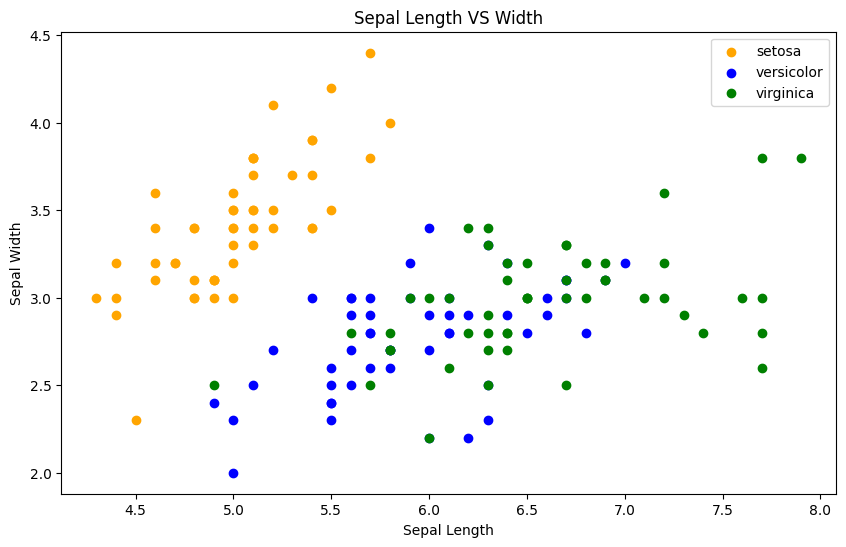

In [6]:
fig, ax = plt.subplots(figsize = (10, 6))

for species, color in [("Iris-setosa", "orange"), ("Iris-versicolor", "blue"), ("Iris-virginica", "green")]: 
    iris_subset = iris.loc[iris.Species == species]
    length = iris_subset.SepalLengthCm
    width = iris_subset.SepalWidthCm
    ax.scatter(x = length, y = width, c = color, label = species.split(sep = "-")[1])

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_title("Sepal Length VS Width")
ax.legend()
tr
plt.show()

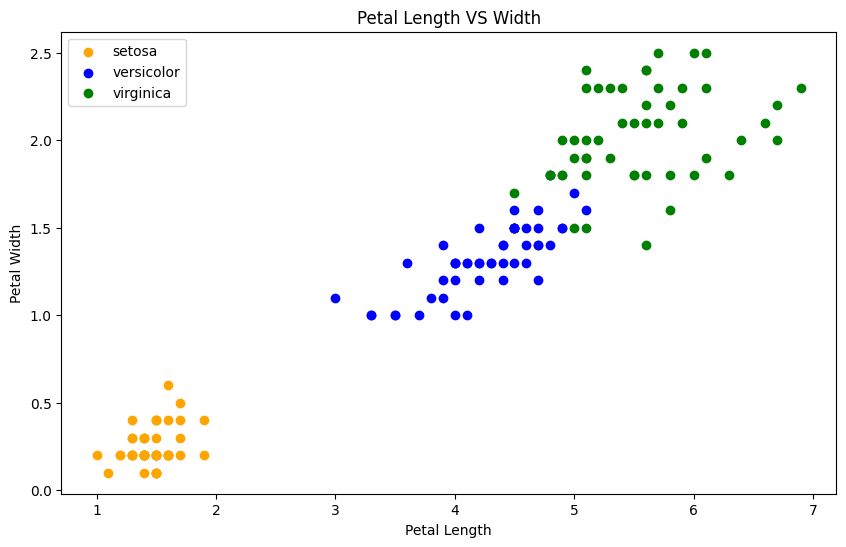

In [7]:
# The above graph show relationship between Sepal Length & Width 
# Now we will check relationship between Petal Length & Width 
fig, ax = plt.subplots(figsize = (10, 6))

for species, color in [("Iris-setosa", "orange"), ("Iris-versicolor", "blue"), ("Iris-virginica", "green")]: 
    iris_subset = iris.loc[iris.Species == species]
    length = iris_subset.PetalLengthCm
    width = iris_subset.PetalWidthCm
    ax.scatter(x = length, y = width, c = color, label = species.split(sep = "-")[1])

ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
ax.set_title("Petal Length VS Width")
ax.legend()

plt.show()

In [8]:
# From the above graph we see that Petal features give a better cluster division 
# compared to the Sepal features. This indicates that the Petals may provide better 
# and more accurate predictions than the Sepals. 

#### Now let us see how length and width are distributed

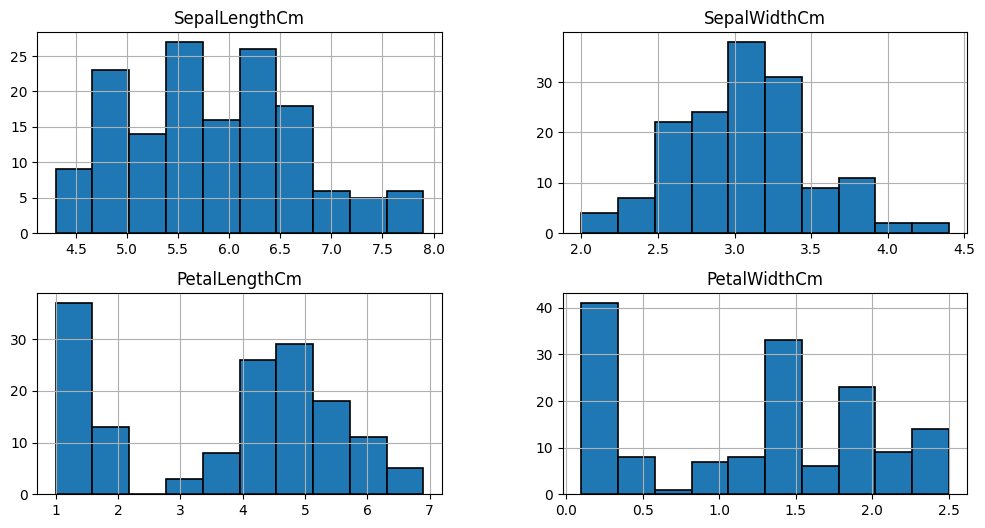

In [9]:
iris.hist(edgecolor = "black", linewidth = 1.2, figsize = (12, 6)) 
plt.show()

#### Now let us see how length and width vary according to the species

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

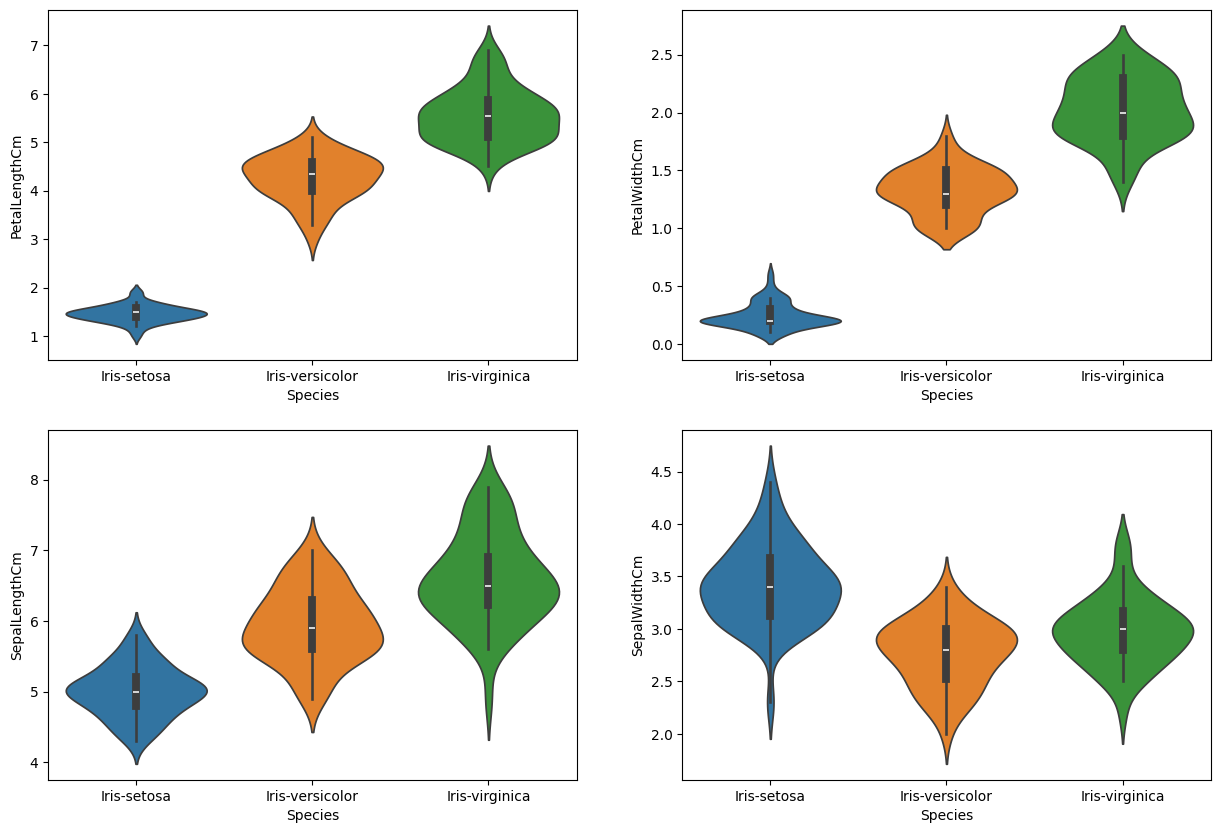

In [10]:
fig, axs = plt.subplots(2, 2, figsize = (15, 10))
sns.violinplot(data = iris, x = "Species", y = "PetalLengthCm", ax = axs[0, 0], hue = "Species")
sns.violinplot(data = iris, x = "Species", y = "PetalWidthCm", ax = axs[0, 1], hue = "Species")
sns.violinplot(data = iris, x = "Species", y = "SepalLengthCm", ax = axs[1, 0], hue = "Species")
sns.violinplot(data = iris, x = "Species", y = "SepalWidthCm", ax = axs[1, 1], hue = "Species")

#### The given problem is a Classification problem. Thus we will use the classification algorithms to build a model.

In [11]:
# Importing all the necessary packages to use the various classification algorithms 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm 
from sklearn import metrics 
from sklearn.tree import DecisionTreeClassifier

In [12]:
# get the shape of the dataset
iris.shape

(150, 5)

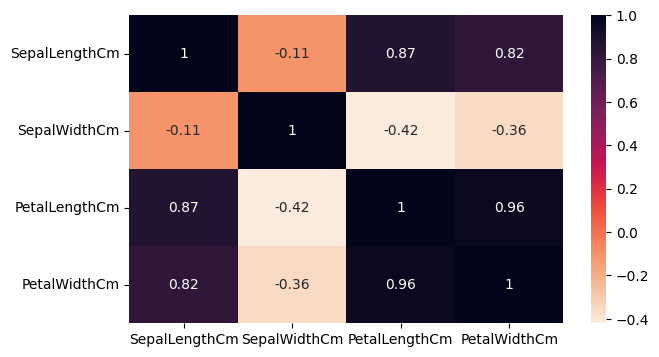

In [22]:
# Identify which features are highly correlated, so as to isolate the rest 
# and get a better prediction model. 
plt.figure(figsize = (7, 4))

# draw a heatmap with input the correlation matrix of the iris DataFrame 
# to see all matplotlib color maps: plt.colormaps()
sns.heatmap(iris.corr(numeric_only = True), annot = True, cmap = "rocket_r")
plt.show()

#### Observation
##### The Petal Width and Petal Length are highly correlated (0.96)

#### Steps to be followed when applying an Algorithm

<ol>
    <li>Split the dataset into training and testing data.The testing dataset is generally smaller.</li>
    <li>Select the appropriate algorithm (classification or regression).</li>
    <li>Pass the training set to the algorithm to train it using the <b>fit()</b> method.</li>
    <li>Pass the testing data to the trained model to predict the outcome, using the <b>predict()</b> method.</li>
    <li>Check the accuracy of the model comparing the predicted outcome with the actual values.</li>
</ol>

### Splitting the data into Training and Testing Dataset

In [23]:
# Our main data is split into training and test. 
# The attribute test_size = 0.3 split the data into 70% train and 30% test. 
train, test = train_test_split(iris, test_size = 0.3)
print(train.shape)
print(test.shape)

(105, 5)
(45, 5)


In [24]:
# Taking the training data features
train_X = train[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
train_y = train.Species # the label (or output) of the training data
# Taking the test data features
test_X = test[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
test_y = test.Species # the label (or output) of the testing data

In [25]:
train_X.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
25,5.0,3.0,1.6,0.2
94,5.6,2.7,4.2,1.3


In [26]:
test_X.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
92,5.8,2.6,4.0,1.2
82,5.8,2.7,3.9,1.2


In [27]:
train_y.head() # output of the training data

25         Iris-setosa
94     Iris-versicolor
102     Iris-virginica
43         Iris-setosa
28         Iris-setosa
Name: Species, dtype: object

#### SVM (Support Vector Machine)

In [32]:
model = svm.SVC() # select the algorithm (Support Vector Classification) 
model.fit(train_X, train_y) # train the algorithm with the training features and output
prediction = model.predict(test_X) # pass the testing features to the trained algorithm

# check the accuracy of the algorithm, passing the model predicted output and the actual output
print(f"The accuracy of the SVM is: {metrics.accuracy_score(prediction, test_y):.1f}")

The accuracy of the SVM is: 1.0


### Logistic Regression

In [34]:
model = LogisticRegression()
model.fit(train_X, train_y)
prediction = model.predict(test_X)
print(f"The accuracy of the Logistic Regression is: {metrics.accuracy_score(prediction, test_y):.2f}")

The accuracy of the Logistic Regression is: 0.96


### Decision Tree

In [37]:
model = DecisionTreeClassifier()
model.fit(train_X, train_y)
prediction = model.predict(test_X) 
print(f"The accuracy of the Decision Tree is: {metrics.accuracy_score(prediction, test_y):.2f}")

The accuracy of the Decision Tree is: 0.93


### K-Nearest Neighbors

In [38]:
# Examine three neighbors for putting the data into a class 
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(train_X, train_y)
prediction = model.predict(test_X)
print(f"The accuracy of the KNN is: {metrics.accuracy_score(prediction, test_y):.2f}")

The accuracy of the KNN is: 0.96


#### Check the accuracy for various values of n for K-Nearest Neighbors

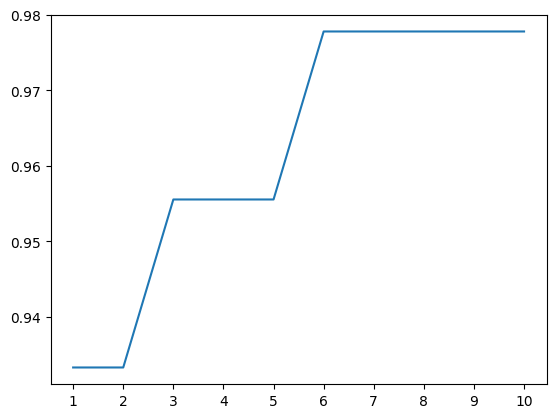

In [44]:
a_index = list(range(1, 11))
a = []

for i in a_index:
    model = KNeighborsClassifier(n_neighbors = i) 
    model.fit(train_X, train_y) 
    prediction = model.predict(test_X) 
    a.append(metrics.accuracy_score(prediction, test_y))

plt.plot(a_index, a)
plt.xticks(a_index)
plt.show()

#### We used all the features of iris in the above models. Now we will use Petals and Sepals separately

#### Creating Petals and Sepals Training Data

In [45]:
petal = iris[["PetalLengthCm", "PetalWidthCm", "Species"]]
sepal = iris[["SepalLengthCm", "SepalWidthCm", "Species"]]

In [46]:
# petals
train_p, test_p = train_test_split(petal, test_size = 0.3, random_state = 0)
train_x_p = train_p[["PetalWidthCm", "PetalLengthCm"]]
train_y_p = train_p.Species
test_x_p = test_p[["PetalWidthCm", "PetalLengthCm"]]
test_y_p = test_p.Species 

# sepals
train_s, test_s = train_test_split(sepal, test_size = 0.3, random_state = 0) 
train_x_s = train_s[["SepalWidthCm", "SepalLengthCm"]]
train_y_s = train_s.Species
test_x_s = test_s[["SepalWidthCm", "SepalLengthCm"]]
test_y_s = test_s.Species 

#### SVM

In [48]:
model = svm.SVC() 
model.fit(train_x_p, train_y_p) 
prediction = model.predict(test_x_p) 
print(f"The accuracy of the SVM using Petals is: {metrics.accuracy_score(prediction, test_y_p):.2f}")

model = svm.SVC() 
model.fit(train_x_s, train_y_s) 
prediction = model.predict(test_x_s) 
print(f"The accuracy of the SVM using Sepals is: {metrics.accuracy_score(prediction, test_y_s):.2f}")

The accuracy of the SVM using Petals is: 0.98
The accuracy of the SVM using Sepals is: 0.80


#### Logistic Regression

In [51]:
model = LogisticRegression() 
model.fit(train_x_p, train_y_p) 
prediction = model.predict(test_x_p) 
print(f"The accuracy of the Logistic Regression using Petals is: {metrics.accuracy_score(prediction, test_y_p):.2f}")

model = LogisticRegression() 
model.fit(train_x_s, train_y_s) 
prediction = model.predict(test_x_s) 
print(f"The accuracy of the Logistic Regression using Sepals is: {metrics.accuracy_score(prediction, test_y_s):.2f}")

The accuracy of the Logistic Regression using Petals is: 0.98
The accuracy of the Logistic Regression using Sepals is: 0.82


#### Decision Tree

In [54]:
model = DecisionTreeClassifier()
model.fit(train_x_p, train_y_p) 
prediction = model.predict(test_x_p) 
print(f"The accuracy of the Decision Tree using Petals is: {metrics.accuracy_score(prediction, test_y_p):.2f}")

model = DecisionTreeClassifier()
model.fit(train_x_s, train_y_s) 
prediction = model.predict(test_x_s) 
print(f"The accuracy of the Decision Tree using Sepals is: {metrics.accuracy_score(prediction, test_y_s):.2f}")

The accuracy of the Decision Tree using Petals is: 0.96
The accuracy of the Decision Tree using Sepals is: 0.64


#### K-Nearest Neighbors

In [56]:
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(train_x_p, train_y_p) 
prediction = model.predict(test_x_p) 
print(f"The accuracy of the KNN using Petals is: {metrics.accuracy_score(prediction, test_y_p):.2f}")

model = KNeighborsClassifier(n_neighbors = 3)
model.fit(train_x_s, train_y_s) 
prediction = model.predict(test_x_s) 
print(f"The accuracy of the KNN using Sepals is: {metrics.accuracy_score(prediction, test_y_s):.2f}")

The accuracy of the KNN using Petals is: 0.98
The accuracy of the KNN using Sepals is: 0.73
